# Self-Reflective RAG (Adaptive & Corrective RAG with LangGraph)

This notebook implements an **Agentic, Self-Reflective RAG system** using **LangChain**, **LangGraph**, **ChromaDB**, and **Open Knowledge Document & Embedding Formatting**.

### Core Architecture & Capabilities:
1. **Open Knowledge Formatting**: Standardizes document chunks with contextual knowledge source tags, document titles, and page citations for high-accuracy embedding representations and grounded generation.
2. **Flexible Embeddings**: Integrates high-dimensional vector embeddings (OpenAI `text-embedding-3-small`, Google GenAI `text-embedding-004`, or Ollama) with ChromaDB.
3. **Agentic Routing**: Automatically routes questions to internal Vectorstore RAG, external Web Search, or Direct Response.
4. **Document Relevance Grading**: Evaluates retrieved document chunks and filters out noise.
5. **Conditional Web Search**: Queries DuckDuckGo dynamically if retrieved context is insufficient or if public/current information is required.
6. **Self-Reflection & Evaluation**:
   - **Hallucination Grader**: Ensures the answer is strictly grounded in the retrieved facts.
   - **Answer Utility Grader**: Assesses whether the answer directly resolves the user query.
7. **Controlled Reasoning Loop**: Tracks loop iterations (`loop_step`) with strict retry limits (`max_retries`) to avoid runaway LLM calls.
8. **Optimized Prompts & Structured Outputs**: Employs Pydantic structured schemas for deterministic boolean decisions and lean reasoning.

### 1. Imports & Environment Setup

In [1]:
import os
import json
import time
from typing import List, TypedDict, Literal, Optional
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, START, END

# Load environment variables (.env)
load_dotenv()

C:\Users\ayush\AppData\Local\Temp\ipykernel_5832\2302171398.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

### 2. Document Loading & Open Knowledge Chunk Formatting
Here we load PDF documents and format each chunk using **Open Knowledge Formatting** (enriching text with knowledge source tags, document titles, and page numbers for transparent citations and optimal embedding representations).

In [2]:
# 1. Load PDF documents from the local documents folder
raw_docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

# 2. Split documents into semantically coherent base chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=150
)
raw_chunks = text_splitter.split_documents(raw_docs)

# 3. Apply Open Knowledge Formatting to each chunk
# Enriches chunks with structured metadata and contextual headers before embedding
formatted_chunks = []
for i, chunk in enumerate(raw_chunks):
    source_file = os.path.basename(chunk.metadata.get("source", "Unknown_Document"))
    page_num = chunk.metadata.get("page", 0) + 1
    doc_title = os.path.splitext(source_file)[0].replace("_", " ")
    clean_text = chunk.page_content.strip()
    
    # Standardized Open Knowledge Structured Representation
    open_knowledge_content = (
        f"[KNOWLEDGE SOURCE: {doc_title}] [FILE: {source_file}] [PAGE: {page_num}]\n"
        f"--------------------------------------------------\n"
        f"{clean_text}"
    )
    
    enriched_doc = Document(
        page_content=open_knowledge_content,
        metadata={
            **chunk.metadata,
            "source_file": source_file,
            "doc_title": doc_title,
            "page_number": page_num,
            "chunk_id": f"{source_file}_p{page_num}_chunk{i+1}",
            "format": "open_knowledge_standard"
        }
    )
    formatted_chunks.append(enriched_doc)

print(f"Loaded {len(raw_docs)} document pages.")
print(f"Generated {len(formatted_chunks)} Open Knowledge formatted chunks ready for embedding.\n")
print("--- Sample Open Knowledge Formatted Chunk ---")
print(formatted_chunks[0].page_content[:320] + "...")

incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams


Loaded 8 document pages.
Generated 16 Open Knowledge formatted chunks ready for embedding.

--- Sample Open Knowledge Formatted Chunk ---
[KNOWLEDGE SOURCE: Company Policies] [FILE: Company_Policies.pdf] [PAGE: 1]
--------------------------------------------------
NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination....


### 3. LLM, Embeddings & Chroma Open Knowledge Vector Store Setup

In [3]:
# 1. Initialize Primary & Fallback LLMs
primary_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
fallback_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
llm = primary_llm.with_fallbacks([fallback_llm])

# 2. Vector Embeddings Setup (Open Knowledge Embeddings)
# Prioritizes OpenAI text-embedding-3-small, with Google GenAI / Ollama fallbacks
if os.getenv("OPENAI_API_KEY") and not os.getenv("OPENAI_API_KEY").startswith("your_"):
    print("Initializing OpenAI Embeddings (text-embedding-3-small)...")
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
elif os.getenv("GOOGLE_API_KEY") and not os.getenv("GOOGLE_API_KEY").startswith("your_"):
    print("Initializing Google Generative AI Embeddings (models/text-embedding-004)...")
    embeddings = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")
else:
    print("Initializing Ollama Embeddings (mxbai-embed-large)...")
    embeddings = OllamaEmbeddings(
        model="mxbai-embed-large",
        base_url="http://localhost:11434"
    )

# 3. Chroma Open Knowledge Vector Store
persist_directory = "./chroma_db"
collection_name = "company_open_knowledge_base"

if os.path.exists(persist_directory):
    try:
        print("Connecting to existing Chroma vector database...")
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings,
            collection_name=collection_name
        )
        if vector_store._collection.count() == 0:
            print("Collection empty. Indexing Open Knowledge formatted chunks...")
            vector_store = Chroma.from_documents(
                documents=formatted_chunks,
                embedding=embeddings,
                persist_directory=persist_directory,
                collection_name=collection_name
            )
        else:
            print(f"Loaded existing collection '{collection_name}' with {vector_store._collection.count()} vectors.")
    except Exception as e:
        print(f"Re-indexing Chroma with updated embedding configuration ({e})...")
        vector_store = Chroma.from_documents(
            documents=formatted_chunks,
            embedding=embeddings,
            persist_directory=persist_directory,
            collection_name=collection_name
        )
else:
    print("Creating Chroma Open Knowledge vector database for the first time...")
    vector_store = Chroma.from_documents(
        documents=formatted_chunks,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )

retriever = vector_store.as_retriever(search_kwargs={"k": 4})
print(f"Open Knowledge Retriever ready with {vector_store._collection.count()} vectors.")

Initializing OpenAI Embeddings (text-embedding-3-small)...
Connecting to existing Chroma vector database...
Collection empty. Indexing Open Knowledge formatted chunks...
Open Knowledge Retriever ready with 16 vectors.


### 4. Structured Schemas & Optimized Prompts

In [4]:
# Pydantic Schemas for Deterministic Structured Output

class RouteQuery(BaseModel):
    """Route query to vectorstore, web_search, or direct conversational generation."""
    datasources: Literal["vectorstore", "web_search", "direct"] = Field(
        ...,
        description="Given a user question choose to route it to vectorstore (company documents, policies, products, pricing), web_search (current events, general/external info), or direct (greetings/casual)."
    )

class GradeDocument(BaseModel):
    """Binary score for document relevance assessment."""
    binary_score: Literal["yes", "no"] = Field(
        ...,
        description="Document is relevant to the question: 'yes' or 'no'"
    )

class GradeHallucination(BaseModel):
    """Binary score for hallucination check on generation against facts."""
    binary_score: Literal["yes", "no"] = Field(
        ...,
        description="Answer is grounded in and supported by the context: 'yes' or 'no'"
    )

class GradeAnswer(BaseModel):
    """Binary score for answer usefulness in addressing the question."""
    binary_score: Literal["yes", "no"] = Field(
        ...,
        description="Answer addresses and resolves the user's question: 'yes' or 'no'"
    )

### 5. LLM Chains (Router, Graders, Generator, Rewriter, Evaluators)

In [5]:
# 1. Question Router Chain
router_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert routing assistant for a document-based RAG system.

The system has three possible routes:

1. "vectorstore"
   Use this route when the user's question can be answered using information contained in the files stored inside the "document" folder.
   
   The "document" folder is located in the same directory as this notebook.
   It may contain any type of supported files, such as:
   - PDF
   - TXT
   - DOC/DOCX
   - CSV
   - XLS/XLSX
   - JSON
   - Markdown
   - PPT/PPTX
   - or other readable document/data files.

   Route to "vectorstore" when the question asks about, refers to, searches for,
   summarizes, compares, extracts, or analyzes information that may exist in those files.

2. "web_search"
   Use this route when the answer requires information that is NOT expected to be
   present in the local "document" folder, especially:
   - current or real-time information
   - recent news
   - latest events
   - current prices or statistics
   - external websites
   - general technical documentation
   - information published after the local documents
   - topics completely unrelated to the local documents.

3. "direct"
   Use this route for simple conversational requests that do not require document
   retrieval or web search, such as:
   - greetings
   - thanks
   - goodbyes
   - simple acknowledgements
   - casual conversation.

IMPORTANT ROUTING RULES:
- Prefer "vectorstore" whenever the question could reasonably be answered from the
  local files in the "document" folder.
- Do NOT use "web_search" just because the question is technical if the required
  information may exist in the local documents.
- Use "web_search" when fresh/external information is explicitly required.
- Use "direct" only when neither local documents nor web information is needed.
- Return ONLY one route name:
  "vectorstore", "web_search", or "direct".

Examples:
- "What does the uploaded report say about the project?" → vectorstore
- "Summarize the PDF in the document folder." → vectorstore
- "What are the key findings in the dataset?" → vectorstore
- "Compare the two documents." → vectorstore
- "What is the latest version of Python?" → web_search
- "What happened in the news today?" → web_search
- "Hi, how are you?" → direct
- "Thank you" → direct
"""),
    ("human", "{question}")
])
question_router = router_prompt | llm.with_structured_output(RouteQuery)

# 2. Document Relevance Grader Chain
doc_grader_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader assessing relevance of an Open Knowledge retrieved document chunk to a user question.
If the document chunk contains keywords or semantic meaning related to the user question, grade it as 'yes'.
Otherwise, grade it as 'no'."""),
    ("human", "Retrieved Open Knowledge Document:\n\n{document}\n\nUser question: {question}")
])
doc_grader = doc_grader_prompt | llm.with_structured_output(GradeDocument)

# 3. RAG Answer Generator Chain
rag_gen_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an assistant for question-answering tasks.
Use the following retrieved Open Knowledge context to answer the question clearly, concisely, and factually.
Cite the knowledge source and document name if applicable.
If the context does not contain the answer, state clearly that you do not have enough information.

Retrieved Open Knowledge Context:
{context}"""),
    ("human", "{question}")
])
rag_chain = rag_gen_prompt | llm | StrOutputParser()

# 4. Direct Conversational Chain
direct_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful, courteous AI assistant. Answer the user politely and concisely."),
    ("human", "{question}")
])
direct_chain = direct_prompt | llm | StrOutputParser()

# 5. Query Rewriter Chain (Transform query for search/retrieval)
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a query optimizer that converts an input question into a refined, keyword-rich search query optimized for vectorstore or web search.
Output ONLY the optimized query without preamble or explanation."""),
    ("human", "Initial question:\n{question}\n\nOptimized query:")
])
query_rewriter = rewrite_prompt | llm | StrOutputParser()

# 6. Hallucination Grader Chain
hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts.
Give 'yes' if the answer is completely supported by the facts. Give 'no' if the answer contains unsupported claims or hallucinations."""),
    ("human", "Set of facts (Open Knowledge context):\n\n{documents}\n\nLLM Generation: {generation}")
])
hallucination_grader = hallucination_prompt | llm.with_structured_output(GradeHallucination)

# 7. Answer Utility Grader Chain
answer_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a grader assessing whether an answer addresses / resolves a user question.
Give 'yes' if the answer directly answers the question, or 'no' if it is evasive, incomplete, or off-topic."""),
    ("human", "User question: {question}\n\nLLM Generation: {generation}")
])
answer_grader = answer_prompt | llm.with_structured_output(GradeAnswer)

# Web Search Tool
web_search_tool = DuckDuckGoSearchRun()

### 6. Graph State & Node Definitions

In [6]:
class GraphState(TypedDict):
    """
    Represents the state of the Self-Reflective RAG graph.
    """
    question: str
    generation: str
    documents: List[Document]
    web_search: bool
    loop_step: int
    max_retries: int

# --- Graph Nodes ---

def retrieve(state: GraphState):
    """Retrieve relevant Open Knowledge documents from Chroma vectorstore."""
    print("\n---NODE: RETRIEVING OPEN KNOWLEDGE DOCUMENTS---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {
        "documents": documents,
        "question": question,
        "loop_step": state.get("loop_step", 0),
        "max_retries": state.get("max_retries", 2)
    }

def grade_documents(state: GraphState):
    """Grade retrieved documents for relevance and filter out irrelevant ones."""
    print("\n---NODE: GRADING RETRIEVED DOCUMENTS---")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []
    web_search_needed = False

    for doc in documents:
        try:
            score = doc_grader.invoke({"question": question, "document": doc.page_content})
            grade = score.binary_score.lower()
        except Exception:
            grade = "yes"
        
        if grade == "yes":
            print("  -> Document RELEVANT")
            filtered_docs.append(doc)
        else:
            print("  -> Document NOT RELEVANT")
            web_search_needed = True

    if len(filtered_docs) == 0:
        web_search_needed = True

    return {
        "documents": filtered_docs,
        "question": question,
        "web_search": web_search_needed,
        "loop_step": state.get("loop_step", 0)
    }

def generate(state: GraphState):
    """Generate answer using retrieved Open Knowledge documents & RAG chain."""
    print("\n---NODE: GENERATING ANSWER---")
    question = state["question"]
    documents = state.get("documents", [])
    formatted_docs = "\n\n".join(doc.page_content for doc in documents)
    generation = rag_chain.invoke({"context": formatted_docs, "question": question})
    return {
        "documents": documents,
        "question": question,
        "generation": generation,
        "loop_step": state.get("loop_step", 0)
    }

def direct_generate(state: GraphState):
    """Handle conversational / general direct response."""
    print("\n---NODE: DIRECT GENERATION---")
    question = state["question"]
    generation = direct_chain.invoke({"question": question})
    return {"question": question, "generation": generation}

def transform_query(state: GraphState):
    """Rewrite query to improve retrieval or web search results."""
    print("\n---NODE: TRANSFORMING QUERY---")
    question = state["question"]
    documents = state.get("documents", [])
    better_question = query_rewriter.invoke({"question": question})
    loop_step = state.get("loop_step", 0) + 1
    print(f"  -> Optimized Query: '{better_question}' (Iteration {loop_step})")
    return {
        "documents": documents,
        "question": better_question,
        "loop_step": loop_step
    }

def web_search_node(state: GraphState):
    """Perform external web search and append results in Open Knowledge format."""
    print("\n---NODE: EXECUTING WEB SEARCH---")
    question = state["question"]
    documents = state.get("documents", [])
    try:
        search_results = web_search_tool.run(question)
        web_doc = Document(
            page_content=(
                f"[KNOWLEDGE SOURCE: DuckDuckGo Web Search] [TOPIC: External Search]\n"
                f"--------------------------------------------------\n"
                f"{search_results}"
            ),
            metadata={"source": "DuckDuckGo Web Search", "source_file": "Web Search", "format": "open_knowledge_standard"}
        )
        documents.append(web_doc)
    except Exception as e:
        print(f"  -> Web search warning: {e}")
    return {"documents": documents, "question": question}

### 7. Conditional Routing Logic & LangGraph Workflow

In [7]:
# --- Conditional Edge Routing Functions ---

def route_question(state: GraphState):
    """Adaptive routing at START: vectorstore vs web_search vs direct."""
    print("\n---ROUTER: ASSESSING QUESTION DATASOURCE---")
    question = state["question"]
    try:
        source = question_router.invoke({"question": question})
        decision = source.datasources.lower()
    except Exception:
        decision = "vectorstore"

    if decision == "web_search":
        print("  -> DECISION: ROUTE TO WEB SEARCH")
        return "web_search"
    elif decision == "direct":
        print("  -> DECISION: ROUTE TO DIRECT GENERATION")
        return "direct_generate"
    else:
        print("  -> DECISION: ROUTE TO VECTORSTORE RAG")
        return "vectorstore"

def decide_to_generate(state: GraphState):
    """Post-grading decision: generate answer or rewrite query & web search."""
    print("\n---ROUTER: DECIDING GENERATION VS WEB SEARCH---")
    web_search_flag = state.get("web_search", False)
    loop_step = state.get("loop_step", 0)
    max_retries = state.get("max_retries", 2)

    if web_search_flag and loop_step < max_retries:
        print("  -> DECISION: FILTERED DOCS INSUFFICIENT, TRANSFORMING QUERY & SEARCHING WEB")
        return "transform_query"
    else:
        print("  -> DECISION: SUFFICIENT DOCS AVAILABLE, PROCEEDING TO GENERATE")
        return "generate"
    
def grade_generation_v_documents_and_question(state: GraphState):
    """Self-reflection: Check hallucination (grounding) and utility (answer relevance)."""
    print("\n---SELF-REFLECTION: EVALUATING GENERATION QUALITY---")
    question = state["question"]
    documents = state.get("documents", [])
    generation = state.get("generation", "")
    loop_step = state.get("loop_step", 0)
    max_retries = state.get("max_retries", 2)

    if loop_step >= max_retries:
        print(f"  -> MAX RETRIES ({max_retries}) REACHED. Yielding current answer.")
        return "useful"

    # 1. Hallucination / Grounding Check
    formatted_docs = "\n\n".join(doc.page_content for doc in documents)
    try:
        hallucination_score = hallucination_grader.invoke({
            "documents": formatted_docs,
            "generation": generation
        })
        is_grounded = hallucination_score.binary_score.lower() == "yes"
    except Exception:
        is_grounded = True

    if is_grounded:
        print("  -> GROUNDING CHECK PASSED: Generation is supported by facts.")
        # 2. Answer Relevance / Utility Check
        try:
            answer_score = answer_grader.invoke({
                "question": question,
                "generation": generation
            })
            is_useful = answer_score.binary_score.lower() == "yes"
        except Exception:
            is_useful = True

        if is_useful:
            print("  -> UTILITY CHECK PASSED: Answer resolves the user query.")
            return "useful"
        else:
            print("  -> UTILITY CHECK FAILED: Answer does not resolve query. Retrying with query rewrite...")
            return "not_useful"
    else:
        print("  -> GROUNDING CHECK FAILED: Hallucination detected. Regenerating...")
        return "not_grounded"

# --- Assemble Graph Workflow ---
workflow = StateGraph(GraphState)

# 1. Add Nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("direct_generate", direct_generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search", web_search_node)

# 2. Build Graph Edges
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "vectorstore": "retrieve",
        "web_search": "transform_query",
        "direct_generate": "direct_generate"
    }
)

workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate"
    }
)

workflow.add_edge("transform_query", "web_search")
workflow.add_edge("web_search", "generate")

workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "useful": END,
        "not_useful": "transform_query",
        "not_grounded": "generate"
    }
)

workflow.add_edge("direct_generate", END)

# 3. Compile the StateGraph
app = workflow.compile()
print("Self-Reflective RAG Graph compiled successfully!")

Self-Reflective RAG Graph compiled successfully!


### 8. Visualize Graph Architecture

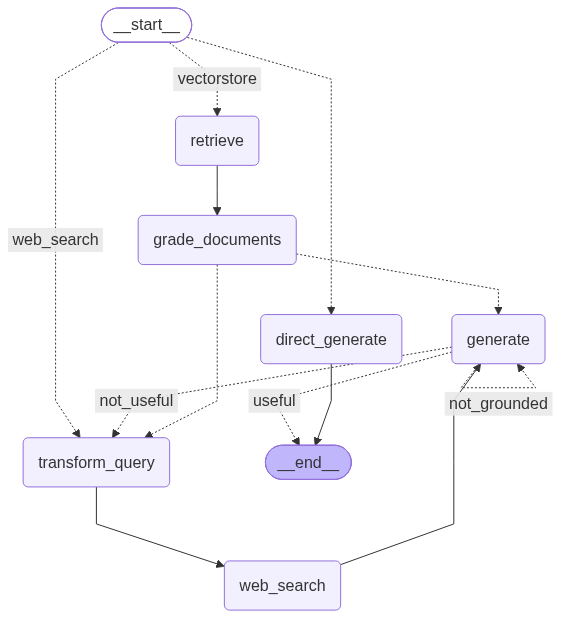

In [8]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render Mermaid PNG (requires pygraphviz/mermaid): {e}")
    print(app.get_graph().draw_mermaid())

### 9. Test Pipeline on Multiple Scenarios

In [9]:
def run_pipeline(question: str):
    print("=" * 60)
    print(f"USER QUESTION: {question}")
    print("=" * 60)
    inputs = {"question": question, "max_retries": 2, "loop_step": 0}
    final_generation = None
    for output in app.stream(inputs):
        for key, value in output.items():
            print(f"Completed Step -> {key}")
            if "generation" in value and value["generation"]:
                final_generation = value["generation"]
    print("\n" + "*" * 30 + " FINAL ANSWER " + "*" * 30)
    print(final_generation)
    print("*" * 74 + "\n")

# Test 1: Internal RAG Question (NexaAI Company Profile / Leadership)
run_pipeline("Who is the CEO of NexaAI?")

# Test 2: External / General Web Search Question
run_pipeline("What are the major AI advancements announced by OpenAI recently?")

# Test 3: Direct Conversational Greeting
run_pipeline("Hello, how can you help me today?")

USER QUESTION: Who is the CEO of NexaAI?

---ROUTER: ASSESSING QUESTION DATASOURCE---
  -> DECISION: ROUTE TO WEB SEARCH

---NODE: TRANSFORMING QUERY---
  -> Optimized Query: 'NexaAI CEO 2023' (Iteration 1)
Completed Step -> transform_query

---NODE: EXECUTING WEB SEARCH---
Completed Step -> web_search

---NODE: GENERATING ANSWER---

---SELF-REFLECTION: EVALUATING GENERATION QUALITY---
  -> GROUNDING CHECK PASSED: Generation is supported by facts.
  -> UTILITY CHECK PASSED: Answer resolves the user query.
Completed Step -> generate

****************************** FINAL ANSWER ******************************
The CEO of Nexa AI in 2023 was Amit Vyas, who is also the Group CEO of Nexa Holding. He leads a diversified group that includes various agencies and consultancies focused on integrated marketing and AI transformation.
**************************************************************************

USER QUESTION: What are the major AI advancements announced by OpenAI recently?

---ROUTER: 